# **Project 1: Working with CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.

# 1. Data Processing (CNN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Load the raw CIFAR-10 dataset

In [2]:
print("Downloading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

Dataset information:

In [3]:
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Pixel value range: [0, 255]


CIFAR-10 classes

In [4]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
          'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Dataset classes: {classes}")

Dataset classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


VISUALIZE SAMPLE IMAGES:

Displaying 10 random images from the dataset...


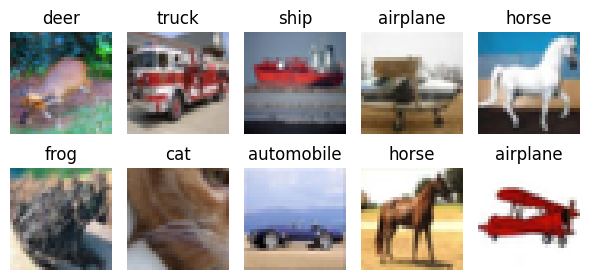

In [5]:
print("Displaying 10 random images from the dataset...")

# Initialize a grid of subplots with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(6,3))

# Flatten the 2D axes array into a 1D array for easier iteration [1, 2, ..., 10]
axes = axes.ravel()


# Iterate to display 10 random samples
for i in range(10):
    # Select a random index from the training set
    idx = np.random.randint(0, len(x_train))
    
    # Render the image at the selected index
    axes[i].imshow(x_train[idx])
    
    # Set the title using the human-readable class name from the 'classes' list
    # Note: y_train[idx][0] accesses the label integer for the selected image
    axes[i].set_title(f"{classes[y_train[idx][0]]}")
    
    # Hide the x and y axes for a cleaner visual presentation
    axes[i].axis('off')

# Adjust the layout to prevent titles from overlapping
plt.tight_layout()

# Export the figure as a PNG file for documentation/GitHub README
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')

# Display the final plot
plt.show()

# Normalization (Feature Scaling) (CNN)

In [6]:
# Convert pixel values from [0, 255] to [0, 1] for numerical stability
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0
print(f"Pixel value range: [{x_train_normalized.min()}, {x_train_normalized.max()}]")

Pixel value range: [0.0, 1.0]


# Preparing Labels: One-Hot Encoding (CNN)

In [7]:
# Convert class vectors (integers) to binary class matrices
# Necessary for the Categorical Crossentropy loss function

num_classes = 10
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

print(f"Shape of y_train after one-hot encoding: {y_train_encoded.shape}")
print(f"Shape of y_test after one-hot encoding: {y_test_encoded.shape}")


Shape of y_train after one-hot encoding: (50000, 10)
Shape of y_test after one-hot encoding: (10000, 10)


# 2. Model Architecture:  (CNN)
 - Design a CNN architecture suitable for image classification.

In [8]:
# Designing a CNN architecture

print("Creating CNN model...")

def create_cnn_model():
    """
    Constructs a Convolutional Neural Network (CNN) using the Keras Sequential API.
    
    The architecture follows a common pattern: Feature Extraction (Conv + Pool) 
    followed by Classification (Flatten + Dense).
    """
    model = models.Sequential([
        # --- First Convolutional Block ---
        # 32 filters of size 3x3 to extract low-level features (edges, textures).
        # 'padding=same' ensures the output size matches the input size.
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        # Reduce spatial dimensions by half (from 32x32 to 16x16) to focus on the most important features.
        layers.MaxPooling2D((2, 2)),
        # Regularization: Randomly turn off 25% of neurons to prevent 'Overfitting'.
        layers.Dropout(0.25),
        
        # --- Second Convolutional Block ---
        # Increase filter count to 64 to capture more complex patterns (shapes, object parts).
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        # Further downsample the feature maps (from 16x16 to 8x8).
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # --- Classification Head (Fully Connected Layers) ---
        # Flatten the 3D feature maps into a 1D vector to feed into the Dense layers.
        layers.Flatten(),
        # A large hidden layer with 512 neurons to learn the relationships between features.
        layers.Dense(512, activation='relu'),
        # Higher dropout (50%) to ensure the model generalizes well to unseen data.
        layers.Dropout(0.5),
        # Final output layer: 10 neurons (one per CIFAR-10 class) with 'Softmax' 
        # to output a probability distribution.
        layers.Dense(10, activation='softmax')
    ])
    
    return model

# Instantiate the model
model_cnn = create_cnn_model()
# Print the model architecture, parameter count, and output shapes.
model_cnn.summary()

Creating CNN model...


2026-03-03 07:14:04.859740: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-03 07:14:04.859815: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-03 07:14:04.859823: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-03 07:14:04.862792: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 07:14:04.862815: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Compile Model (CNN)

In [9]:
# --- Model Compilation ---
# We define the three essential components for training:
model_cnn.compile(
    # 1. Loss Function: Measures how "wrong" the model's predictions are. 
    # Categorical Crossentropy is the standard for multi-class classification (like CIFAR-10).
    loss='categorical_crossentropy', 
    
    # 2. Optimizer: The algorithm that updates the weights to minimize the loss.
    # 'Adam' it adapts the learning rate automatically.
    optimizer='adam', 
    
    # 3. Metrics: What we want to monitor during training to judge performance.
    metrics=['accuracy']
)

Data Augmentation

In [10]:
print("Configuring data augmentation...")

# Initialize the ImageDataGenerator which will apply random transformations
# to the images in real-time during the training process.
datagen = ImageDataGenerator(
    # Randomly rotate images by up to 15 degrees
    rotation_range=15,
    
    # Randomly shift images horizontally by 10% of the total width
    width_shift_range=0.1,
    
    # Randomly shift images vertically by 10% of the total height
    height_shift_range=0.1,
    
    # Randomly flip images horizontally (ideal for objects like cars or animals)
    horizontal_flip=True,
    
    # Randomly zoom inside pictures by up to 20%
    zoom_range=0.2
)

Configuring data augmentation...


Early Stopping

In [11]:
print("Model CNN - EarlyStopping...")

# Define the EarlyStopping callback to monitor the training process
early_stop = EarlyStopping(
    # Monitor: The metric to watch. We track 'val_loss' to see when the model 
    # stops generalizing to new data.
    monitor='val_loss',
    
    # Patience: The number of epochs to wait after the last improvement. 
    # If val_loss doesn't improve for 10 epochs, training will be terminated.
    patience=10,
    
    # Restore Best Weights: Crucial for performance. Once training stops, the model 
    # will revert to the weights from the epoch with the lowest validation loss, 
    # rather than staying with the final, potentially overfitted weights.
    restore_best_weights=True
)

Model CNN - EarlyStopping...


# 4. Training Model

In [12]:
# --- Training Configuration ---
# Batch Size: The number of images the model looks at before updating its internal weights.

BATCH_SIZE = 128

# Epochs: The maximum number of times the model will go through the entire dataset.
# We set it to 100, but 'EarlyStopping' will likely stop it much sooner to save time.
EPOCHS = 100

# --- The Training Loop ---
# We store the results in 'history_cnn' to plot the learning curves later.
history_cnn = model_cnn.fit(
    # Use the 'datagen' to feed augmented images to the model in real-time
    datagen.flow(x_train_normalized, y_train_encoded, batch_size=BATCH_SIZE),
    
    epochs=EPOCHS,  
    
    # Provide the test set to evaluate how well the model generalizes after each epoch
    validation_data=(x_test_normalized, y_test_encoded),
    
    # Attach our EarlyStopping logic here
    callbacks=[early_stop],
    
    # Verbose=1 shows a progress bar and metrics for each epoch in the console
    verbose=1
)

Epoch 1/100


2026-03-03 07:14:05.675834: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.3630 - loss: 1.7278 - val_accuracy: 0.4961 - val_loss: 1.4316
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.4758 - loss: 1.4814 - val_accuracy: 0.5765 - val_loss: 1.1955
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.4937 - loss: 1.4892 - val_accuracy: 0.5650 - val_loss: 1.2517
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4923 - loss: 1.5426 - val_accuracy: 0.6097 - val_loss: 1.1710
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4917 - loss: 1.7062 - val_accuracy: 0.6166 - val_loss: 1.2056
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4754 - loss: 2.1626 - val_accuracy: 0.5756 - val_loss: 1.6710
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4721 - loss: 2.8419 - val_accuracy: 0.5882 - val_loss: 2.2770
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4574 - loss: 4.6058 - val_

Visualize Training

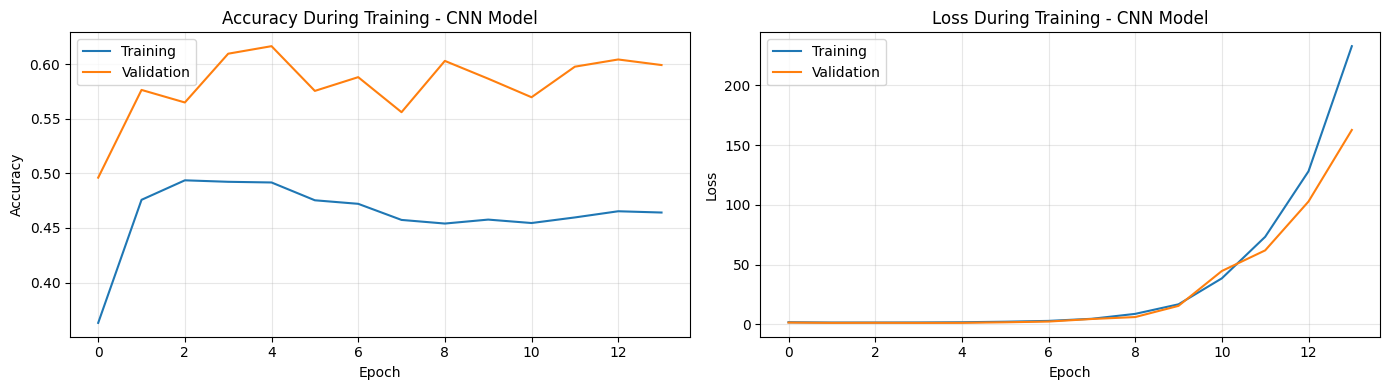

In [13]:
# Create a figure with 1 row and 2 columns of subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left Plot: Training vs. Validation Accuracy ---
# Plot the accuracy of the training data and the unseen validation data per epoch
axes[0].plot(history_cnn.history['accuracy'], label='Training')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0].set_xlabel('Epoch') # The horizontal axis represents passes through the dataset
axes[0].set_ylabel('Accuracy') # The vertical axis represents the percentage of correct predictions
axes[0].set_title('Accuracy During Training - CNN Model')
axes[0].legend() # Show the labels to distinguish between Training and Validation
axes[0].grid(True, alpha=0.3) # Add a subtle grid for better readability

# --- Right Plot: Training vs. Validation Loss ---
# Plot the loss (error) value for both sets. We want these values to decrease.
axes[1].plot(history_cnn.history['loss'], label='Training')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss') # Represents the 'cost' or error of the model
axes[1].set_title('Loss During Training - CNN Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Finalize and export the visualization
plt.tight_layout() # Adjust spacing to prevent overlapping
plt.savefig('training_metrics_cnn.png', dpi=100, bbox_inches='tight') # Save for documentation
plt.show()

# 4. Model Evaluation (CNN)

In [14]:
print("Evaluating CNN Model...")

# Use the 'evaluate' method to get the final loss and accuracy on the unseen test set.
# 'verbose=0' keeps the output clean by hiding the progress bar.
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(x_test_normalized, y_test_encoded, verbose=1)

# Display the final performance metrics. We multiply by 100 for a readable percentage.
print(f"\nAccuracy on test set: {test_accuracy_cnn * 100:.2f}%")
print(f"Loss on test set: {test_loss_cnn:.4f}")

# --- Inference and Predictions ---
# 'predict' returns the raw probabilities for each class (10 values per image).
y_pred_cnn = model_cnn.predict(x_test_normalized)

# Use 'argmax' to find the index of the highest probability (the predicted class).
# 'axis=1' means we look horizontally across the 10 class scores for each image.
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)

# Convert the true labels (one-hot encoded) back to single integers for comparison.
y_test_classes = np.argmax(y_test_encoded, axis=1)

Evaluating CNN Model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6097 - loss: 1.1710

Accuracy on test set: 60.97%
Loss on test set: 1.1710
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


Detailed Metrics: Precision, Recall & F1-score

In [15]:
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_cnn, target_names=classes))

# Calculate global metrics
precision_cnn = precision_score(y_test_classes, y_pred_classes_cnn, average='weighted')
recall_cnn = recall_score(y_test_classes, y_pred_classes_cnn, average='weighted')
f1_cnn = f1_score(y_test_classes, y_pred_classes_cnn, average='weighted')

print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall: {recall_cnn:.4f}")
print(f"F1-Score: {f1_cnn:.4f}")


=== METRICS BY CLASS ===

              precision    recall  f1-score   support

    airplane       0.65      0.73      0.69      1000
  automobile       0.59      0.89      0.71      1000
        bird       0.65      0.31      0.42      1000
         cat       0.59      0.29      0.39      1000
        deer       0.74      0.29      0.42      1000
         dog       0.45      0.70      0.55      1000
        frog       0.51      0.86      0.64      1000
       horse       0.74      0.66      0.70      1000
        ship       0.85      0.67      0.75      1000
       truck       0.64      0.70      0.67      1000

    accuracy                           0.61     10000
   macro avg       0.64      0.61      0.59     10000
weighted avg       0.64      0.61      0.59     10000


=== GLOBAL METRICS ===
Precision: 0.6416
Recall: 0.6097
F1-Score: 0.5925


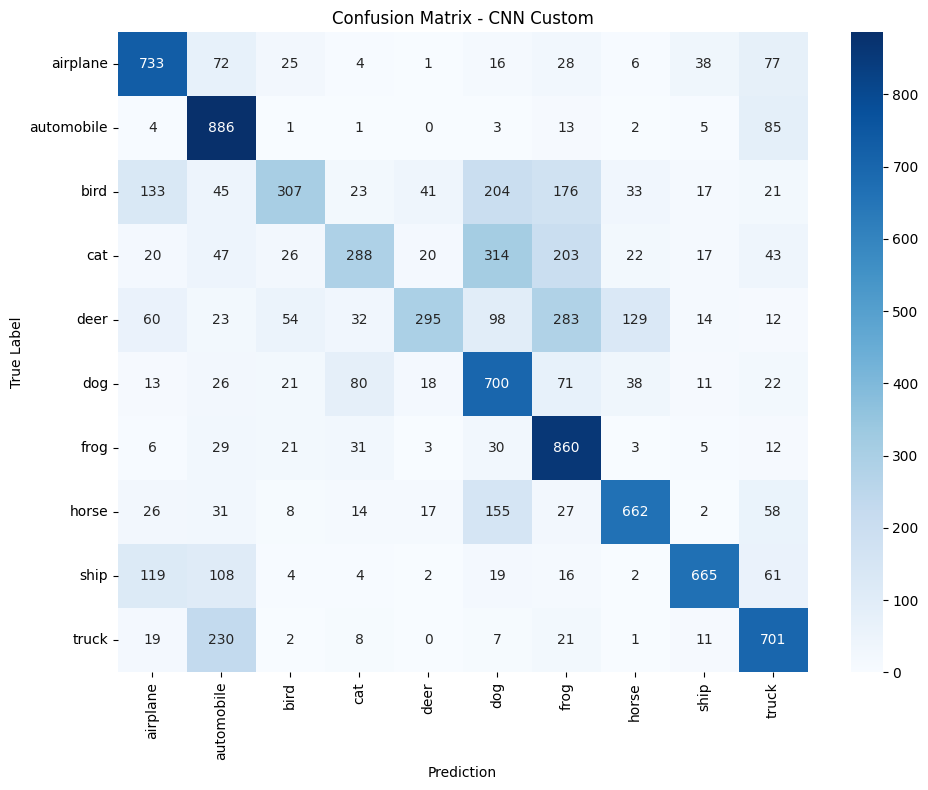

In [16]:
cm_cnn = confusion_matrix(y_test_classes, y_pred_classes_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Prediction')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN Custom')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=100, bbox_inches='tight')
plt.show()

# 5. Transfer Learning
- Evaluate the accuracy of your model on a pre-trained models like ImagNet, VGG16, Inception... (pick one an justify your choice)
- Perform transfer learning with your chosen pre-trained models i.e., you will probably try a few and choose the best one.

In [17]:
print("\n\n=== TRANSFER LEARNING WITH MULTIPLE MODELS ===\n")

early_stop_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



=== TRANSFER LEARNING WITH MULTIPLE MODELS ===



# Transfer Learning with VGG16


In [18]:
base_model_vgg = keras.applications.VGG16(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

In [19]:
# Freeze base model weights
base_model_vgg.trainable = True

In [20]:
model_vgg = models.Sequential([
    base_model_vgg,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [21]:
model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
print("Training VGG16...")
# IMPORTANT: Use the original normalized data (x_train_normalized)
history_vgg = model_vgg.fit(
    x_train_normalized, y_train_encoded,
    epochs=25, # Transfer learning usually needs fewer epochs
    batch_size=128,
    validation_data=(x_test_normalized, y_test_encoded),
    callbacks=[early_stop_tl],
    verbose=1
)

Training VGG16...
Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 65s 157ms/step - accuracy: 0.1000 - loss: 2.3411 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 187ms/step - accuracy: 0.0975 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 187ms/step - accuracy: 0.1009 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 173ms/step - accuracy: 0.1007 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 67s 171ms/step - accuracy: 0.0993 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - accuracy: 0.1006 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 183ms/step - accuracy: 0.1006 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/step - accuracy

In [23]:
# Complete model evaluation: loss/accuracy, classification report, and metrics  VGG16

# Evaluate
test_loss_vgg, test_accuracy_vgg = model_vgg.evaluate(x_test_normalized, y_test_encoded, verbose=0)
print(f" VGG16 Accuracy: {test_accuracy_vgg * 100:.2f}%\n")

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model_vgg.predict(x_test)
y_pred = np.argmax(probs, axis=1)

print("Evaluating VGG16 Model...")

# Use the 'evaluate' method to get the final loss and accuracy on the unseen test set.
# 'verbose=0' keeps the output clean by hiding the progress bar.
test_loss_VGG, test_accuracy_vgg = model_vgg.evaluate(x_test_normalized, y_test_encoded, verbose=1)

# Display the final performance metrics. We multiply by 100 for a readable percentage.
print(f"\nAccuracy on test set: {test_accuracy_vgg * 100:.2f}%")
print(f"Loss on test set: {test_loss_cnn:.4f}")

# --- Inference and Predictions ---
# 'predict' returns the raw probabilities for each class (10 values per image).
y_pred_vgg = model_vgg.predict(x_test_normalized)

# Use 'argmax' to find the index of the highest probability (the predicted class).
# 'axis=1' means we look horizontally across the 10 class scores for each image.
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

# Convert the true labels (one-hot encoded) back to single integers for comparison.
y_test_classes = np.argmax(y_test_encoded, axis=1)

 VGG16 Accuracy: 10.00%

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
Evaluating VGG16 Model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.1000 - loss: 2.3026

Accuracy on test set: 10.00%
Loss on test set: 1.1710
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [24]:
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_vgg, target_names=classes))

# Calculate global metrics
precision_vgg = precision_score(y_test_classes, y_pred_classes_vgg, average='weighted')
recall_vgg = recall_score(y_test_classes, y_pred_classes_vgg, average='weighted')
f1_vgg = f1_score(y_test_classes, y_pred_classes_vgg, average='weighted')

print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_vgg:.4f}")
print(f"Recall: {recall_vgg:.4f}")
print(f"F1-Score: {f1_vgg:.4f}")


=== METRICS BY CLASS ===

              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00      1000
  automobile       0.00      0.00      0.00      1000
        bird       0.00      0.00      0.00      1000
         cat       0.10      1.00      0.18      1000
        deer       0.00      0.00      0.00      1000
         dog       0.00      0.00      0.00      1000
        frog       0.00      0.00      0.00      1000
       horse       0.00      0.00      0.00      1000
        ship       0.00      0.00      0.00      1000
       truck       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000


=== GLOBAL METRICS ===
Precision: 0.0100
Recall: 0.1000
F1-Score: 0.0182


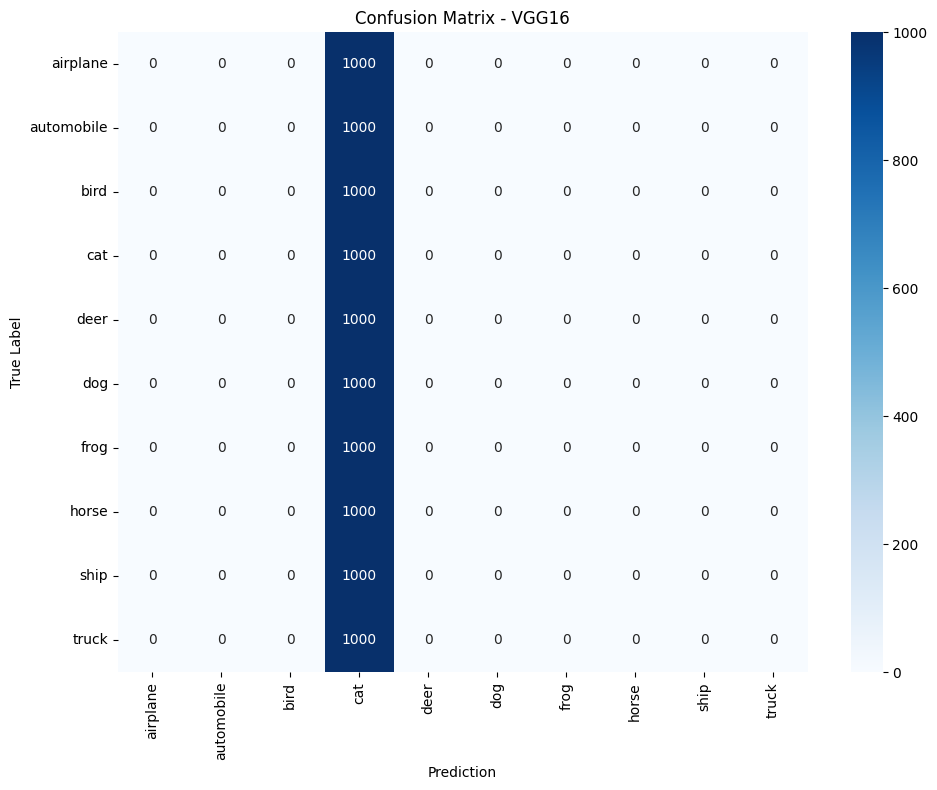

In [25]:
cm_vgg = confusion_matrix(y_test_classes, y_pred_classes_vgg)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Prediction')
plt.ylabel('True Label')
plt.title('Confusion Matrix - VGG16')
plt.tight_layout()
plt.savefig('confusion_matrix_vgg.png', dpi=100, bbox_inches='tight')
plt.show()


# Transfer Learning with MobileNetV2


In [26]:
print("TRAINING MobileNetV2...\n")

base_model_mobilenet = keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

TRAINING MobileNetV2...



In [27]:
# Freeze base model weights
base_model_mobilenet.trainable = True

In [28]:
model_mobilenet = models.Sequential([
    base_model_mobilenet,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [29]:
model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
print("Training MobileNetV2...")
history_mobilenet = model_mobilenet.fit(
    x_train_normalized, y_train_encoded,
    epochs=50,
    batch_size=128,
    validation_data=(x_test_normalized, y_test_encoded),
    callbacks=[early_stop_tl],
    verbose=1
)

Training MobileNetV2...
Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 258s 574ms/step - accuracy: 0.4803 - loss: 1.8571 - val_accuracy: 0.1490 - val_loss: 11.3097
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 162s 412ms/step - accuracy: 0.6258 - loss: 1.3577 - val_accuracy: 0.2140 - val_loss: 10.3405
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 183s 465ms/step - accuracy: 0.6607 - loss: 1.2264 - val_accuracy: 0.1521 - val_loss: 5.0849
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 178s 452ms/step - accuracy: 0.7062 - loss: 0.9551 - val_accuracy: 0.3632 - val_loss: 2.8480
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 175s 446ms/step - accuracy: 0.7290 - loss: 0.8603 - val_accuracy: 0.5767 - val_loss: 1.4928
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 185s 471ms/step - accuracy: 0.7485 - loss: 0.8021 - val_accuracy: 0.5305 - val_loss: 1.7585
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 214s 547ms/step - accuracy: 0.6635 - loss: 1.1051 - val_accuracy: 0.2672 - val_loss: 4.0738
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 216s 550ms

In [31]:
# Complete model evaluation: loss/accuracy, classification report, and metrics  MobileNetV2

# Evaluate
test_loss_mobilenet, test_accuracy_mobilenet = model_mobilenet.evaluate(x_test_normalized, y_test_encoded, verbose=0)
print(f" MobilenetV3 Accuracy: {test_accuracy_mobilenet * 100:.2f}%\n")

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model_mobilenet.predict(x_test)
y_pred = np.argmax(probs, axis=1)


print("Evaluating MobileNetV3...")

# Use the 'evaluate' method to get the final loss and accuracy on the unseen test set.
# 'verbose=0' keeps the output clean by hiding the progress bar.
test_loss_mobilenet, test_accuracy_mobilenet = model_mobilenet.evaluate(x_test_normalized, y_test_encoded, verbose=1)

# Display the final performance metrics. We multiply by 100 for a readable percentage.
print(f"\nAccuracy on test set: {test_accuracy_mobilenet * 100:.2f}%")
print(f"Loss on test set: {test_loss_mobilenet:.4f}")

# --- Inference and Predictions ---
# 'predict' returns the raw probabilities for each class (10 values per image).
y_pred_mobilenet = model_mobilenet.predict(x_test_normalized)

# Use 'argmax' to find the index of the highest probability (the predicted class).
# 'axis=1' means we look horizontally across the 10 class scores for each image.
y_pred_classes_mobilenet = np.argmax(y_pred_mobilenet, axis=1)

# Convert the true labels (one-hot encoded) back to single integers for comparison.
y_test_classes = np.argmax(y_test_encoded, axis=1)

 MobilenetV3 Accuracy: 57.67%

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step
Evaluating MobileNetV3...
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5767 - loss: 1.4928

Accuracy on test set: 57.67%
Loss on test set: 1.4928
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step


In [32]:
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_mobilenet, target_names=classes))

# Calculate global metrics
precision_mobilenet = precision_score(y_test_classes, y_pred_classes_mobilenet, average='weighted')
recall_mobilenet = recall_score(y_test_classes, y_pred_classes_mobilenet, average='weighted')
f1_mobilenet = f1_score(y_test_classes, y_pred_classes_mobilenet, average='weighted')

print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_mobilenet:.4f}")
print(f"Recall: {recall_mobilenet:.4f}")
print(f"F1-Score: {f1_mobilenet:.4f}")


=== METRICS BY CLASS ===

              precision    recall  f1-score   support

    airplane       0.49      0.88      0.63      1000
  automobile       0.94      0.49      0.65      1000
        bird       0.81      0.24      0.37      1000
         cat       0.31      0.75      0.44      1000
        deer       0.56      0.67      0.61      1000
         dog       0.59      0.33      0.43      1000
        frog       0.78      0.72      0.75      1000
       horse       0.91      0.44      0.59      1000
        ship       0.93      0.38      0.53      1000
       truck       0.61      0.86      0.71      1000

    accuracy                           0.58     10000
   macro avg       0.69      0.58      0.57     10000
weighted avg       0.69      0.58      0.57     10000


=== GLOBAL METRICS ===
Precision: 0.6932
Recall: 0.5767
F1-Score: 0.5716


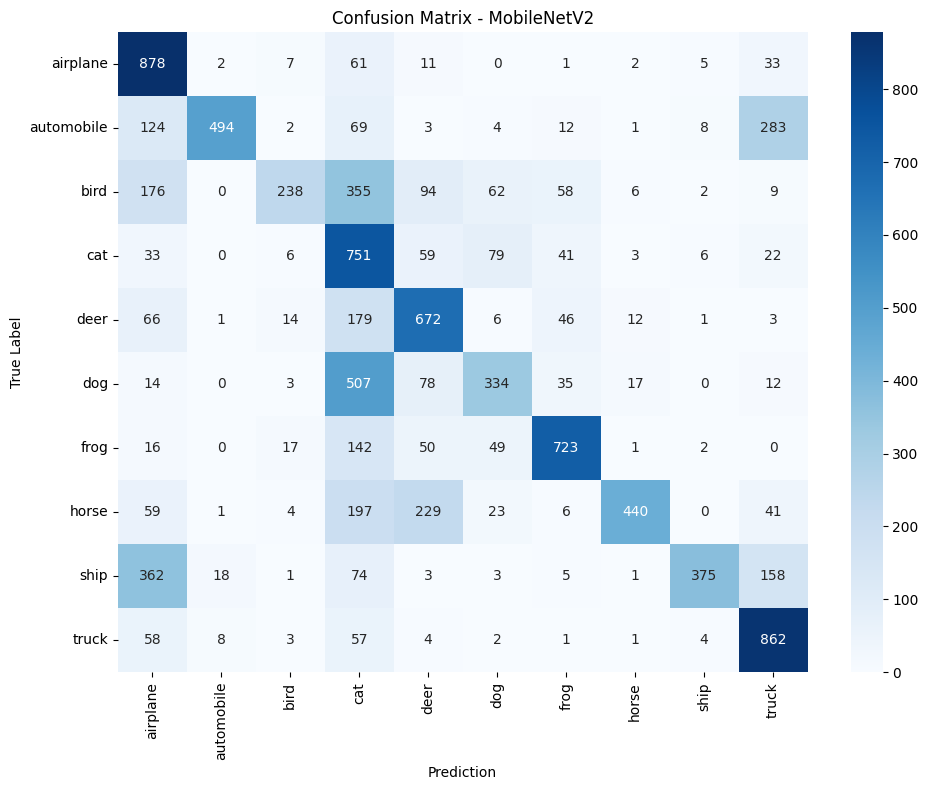

In [33]:
cm_mobilenet = confusion_matrix(y_test_classes, y_pred_classes_mobilenet)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Prediction')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MobileNetV2')
plt.tight_layout()
plt.savefig('confusion_matrix_mobilenet.png', dpi=100, bbox_inches='tight')
plt.show()


# Transfer Learning with InceptionV3


In [34]:
base_model_inception = keras.applications.InceptionV3(
    input_shape=(75, 75, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
# Freeze base model weights
base_model_inception.trainable = False

In [36]:
# Build the model with an internal Resizing layer
model_inception = models.Sequential([
    # Input remains the native CIFAR-10 size (32, 32, 3)
    layers.Input(shape=(32, 32, 3)),
    
    # Dynamic Resizing: Only resizes the current batch to the minimum 75x75
    # This prevents the OOM (Out of Memory) error on your Mac
    layers.Resizing(75, 75),
    
    base_model_inception,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [37]:
model_inception.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
print("Training InceptionV3...")
# Use the original normalized data directly
history_inception = model_inception.fit(
    x_train_normalized, y_train_encoded,
    epochs=20,
    batch_size=64, # Slightly smaller batch to be safe with 75x75 images
    validation_data=(x_test_normalized, y_test_encoded),
    callbacks=[early_stop_tl],
    verbose=1
)

Training InceptionV3...
Epoch 1/20
 29/782 ━━━━━━━━━━━━━━━━━━━━ 35:53 3s/step - accuracy: 0.1243 - loss: 2.8490

KeyboardInterrupt: 

In [ ]:
test_loss_inception, test_accuracy_inception = model_inception.evaluate(x_test_normalized, y_test_encoded, verbose=0)
print(f"InceptionV2 Accuracy: {test_accuracy_inception * 100:.2f}%\n")


In [ ]:
# Complete model evaluation: loss/accuracy, classification report, and metrics  InceptionV3

# Evaluate
test_loss_inception, test_accuracy_inception = model_inception.evaluate(x_test_normalized, y_test_encoded, verbose=0)
print(f"InceptionV2 Accuracy: {test_accuracy_inception * 100:.2f}%\n")

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model_inception.predict(x_test)
y_pred = np.argmax(probs, axis=1)



print("Evaluating InceptionV2...")

# Use the 'evaluate' method to get the final loss and accuracy on the unseen test set.
# 'verbose=0' keeps the output clean by hiding the progress bar.
test_loss_inception, test_accuracy_inception = model_inception.evaluate(x_test_normalized, y_test_encoded, verbose=1)

# Display the final performance metrics. We multiply by 100 for a readable percentage.
print(f"\nAccuracy on test set: {test_accuracy_inception * 100:.2f}%")
print(f"Loss on test set: {test_loss_inception:.4f}")

# --- Inference and Predictions ---
# 'predict' returns the raw probabilities for each class (10 values per image).
y_pred_inception = model_inception.predict(x_test_normalized)

# Use 'argmax' to find the index of the highest probability (the predicted class).
# 'axis=1' means we look horizontally across the 10 class scores for each image.
y_pred_classes_inception = np.argmax(y_pred_inception, axis=1)

# Convert the true labels (one-hot encoded) back to single integers for comparison.
y_test_classes = np.argmax(y_test_encoded, axis=1)

In [ ]:
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_inception, target_names=classes))

# Calculate global metrics
precision_inception = precision_score(y_test_classes, y_pred_classes_inception, average='weighted')
recall_inception = recall_score(y_test_classes, y_pred_classes_inception, average='weighted')
f1_inception = f1_score(y_test_classes, y_pred_classes_inception, average='weighted')

print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_inception:.4f}")
print(f"Recall: {recall_inception:.4f}")
print(f"F1-Score: {f1_inception:.4f}")

In [ ]:
cm_inception = confusion_matrix(y_test_classes, y_pred_classes_inception)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_inception, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Prediction')
plt.ylabel('True Label')
plt.title('Confusion Matrix - InceptionV2')
plt.tight_layout()
plt.savefig('confusion_matrix_inception.png', dpi=100, bbox_inches='tight')
plt.show()


# COMPARISON OF ALL MODELS


In [ ]:
print("\n" + "="*50)
print("=== COMPARISON OF ALL MODELS ===")
print("="*50 + "\n")

results = {
    'CNN Custom': test_accuracy_cnn * 100,
    'VGG16': test_accuracy_vgg * 100,
    'MobileNetV2': test_accuracy_mobilenet * 100,
    'InceptionV3': test_accuracy_inception * 100
}

In [ ]:
# Display results in order
for model_name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:.<30} {accuracy:.2f}%")

In [ ]:
# Identify best model
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print(f" BEST MODEL: {best_model_name} ({best_accuracy:.2f}%)")


In [ ]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(results.keys())
accuracies = list(results.values())
colors = ['gold' if m == best_model_name else 'steelblue' for m in model_names]

bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Comparison - All Models', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

In [ ]:
# Add values on bars
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{accuracy:.2f}%',
            ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


# COMPARE TRAINING CURVES


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CNN Custom
axes[0, 0].plot(history_cnn.history['accuracy'], label='Training')
axes[0, 0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('CNN', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# VGG16
axes[0, 1].plot(history_vgg.history['accuracy'], label='Training')
axes[0, 1].plot(history_vgg.history['val_accuracy'], label='Validation')
axes[0, 1].set_title('VGG16', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# MobileNetV2
axes[1, 0].plot(history_mobilenet.history['accuracy'], label='Training')
axes[1, 0].plot(history_mobilenet.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('MobileNetV2', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# InceptionV3
axes[1, 1].plot(history_inception.history['accuracy'], label='Training')
axes[1, 1].plot(history_inception.history['val_accuracy'], label='Validation')
axes[1, 1].set_title('InceptionV3', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:

# BEST MODEL JUSTIFICATION


print("\n" + "="*50)
print("=== BEST MODEL JUSTIFICATION ===")
print("="*50 + "\n")

justifications = {
    'CNN Custom': """
    - Lightweight and fast to train
    - Low memory usage
    - Good for learning deep learning basics
    - Does not leverage pre-trained features
    """,
    
    'VGG16': """
    - Simple and clear architecture
    - Good classification accuracy
    - More complex than CNN Custom
    - Requires more training time
    """,
    
    'MobileNetV2': """
    - Optimized for mobile devices
    - Very efficient in resource usage
    - Good accuracy-to-speed ratio
    - Ideal for deployment on resource-limited devices
    """,
    
    'InceptionV3': """
    - Complex and powerful architecture
    - Excellent at capturing complex features
    - High accuracy but requires more resources
    - Best for large and complex datasets
    """
}

print(f"✅ SELECTED BEST MODEL: {best_model_name}\n")
print(justifications[best_model_name])

In [ ]:
# =====================================================
# SAVE ALL MODELS
# =====================================================

print("\nSaving all models...\n")
model_cnn.save('model_cnn_custom_cifar10.h5')
print("CNN saved")

model_vgg.save('model_vgg16_cifar10.h5')
print("VGG16 saved")

model_mobilenet.save('model_mobilenetv2_cifar10.h5')
print("MobileNetV2 saved")

model_inception.save('model_inceptionv3_cifar10.h5')
print("InceptionV3 saved")

# Save best model with special name
if best_model_name == 'CNN':
    best_model = model_cnn
elif best_model_name == 'VGG16':
    best_model = model_vgg
elif best_model_name == 'MobileNetV2':
    best_model = model_mobilenet
else:
    best_model = model_inception

best_model.save('best_model_cifar10.h5')
print(f"\nBest model ({best_model_name}) saved as 'best_model_cifar10.h5'")


In [ ]:

# =====================================================
# MAKE PREDICTIONS WITH BEST MODEL
# =====================================================

print("\n" + "="*50)
print("=== PREDICTIONS WITH BEST MODEL ===")
print("="*50 + "\n")

def predict_image_cnn(image, normalized=True):
    """
    Makes prediction on a single image with CNN Custom model.
    Args:
        image: numpy array of image
        normalized: whether data is normalized or not
    """
    if not normalized:
        image = image.astype('float32') / 255.0
    
    image_expanded = np.expand_dims(image, axis=0)
    prediction = model_cnn.predict(image_expanded, verbose=0)
    
    return prediction[0]

def predict_image_transfer(image, model, normalized=True):
    """
    Makes prediction on a single image with transfer learning model.
    """
    if not normalized:
        image = image.astype('float32') / 255.0
    
    image_resized = tf.image.resize(np.expand_dims(image, axis=0), (224, 224))
    prediction = model.predict(image_resized, verbose=0)
    
    return prediction[0]

# Display predictions
print(f"Predictions with {best_model_name}:\n")
for i in range(5):
    idx = np.random.randint(0, len(x_test))
    
    if best_model_name == 'CNN Custom':
        probs = predict_image_cnn(x_test_normalized[idx], normalized=True)
    else:
        probs = predict_image_transfer(x_test_normalized[idx], best_model, normalized=True)
    
    predicted_class = classes[np.argmax(probs)]
    confidence = np.max(probs) * 100
    true_class = classes[y_test_classes[idx]]
    is_correct = "✅" if predicted_class == true_class else "❌"
    
    print(f"\nSample {i+1}: {is_correct}")
    print(f"  True class:      {true_class}")
    print(f"  Prediction:      {predicted_class}")
    print(f"  Confidence:      {confidence:.2f}%")